In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/OnlineRetail.csv", encoding='latin1')


print(df.head())

print(df.shape)

print(df.dtypes)

print(df.describe())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
(541909, 8)
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object
   

### Data Preparation: Create `TotalSales` Column

First, let's create a `TotalSales` column by multiplying `Quantity` and `UnitPrice`. This will be useful for financial analysis.

In [7]:
# Create a TotalSales column for meaningful financial analysis
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

# Display the head of the DataFrame with the new column
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  TotalSales  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom       15.30  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom       20.34  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom       22.00  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom       20.34  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom       20.34  


### Filtering Examples

Let's see how we can filter the data, for instance, to look at canceled transactions or orders from a specific country.

In [8]:
# Filter canceled transactions (invoices starting with 'C')
canceled = df[df["InvoiceNo"].astype(str).str.startswith("C", na=False)]
print("\nCanceled Transactions:")
print(canceled.head())

# Filter by a specific country (e.g., United Kingdom)
uk_orders = df[df["Country"] == "United Kingdom"]
print("\nOrders from United Kingdom:")
print(uk_orders.head())


Canceled Transactions:
    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

         InvoiceDate  UnitPrice  CustomerID         Country  TotalSales  
141   12/1/2010 9:41      27.50     14527.0  United Kingdom      -27.50  
154   12/1/2010 9:49       4.65     15311.0  United Kingdom       -4.65  
235  12/1/2010 10:24       1.65     17548.0  United Kingdom      -19.80  
236  12/1/2010 10:24       0.29     17548.0  United Kingdom       -6.96  
237  12/1/2010 10:24       0.29     17548.0  United Kingdom       -6.96  

Orders from United Kingdom:
  InvoiceNo StockCode                          Description  Quantity  \
0   

### Sorting Data

We can sort the data to find the highest or lowest values for a particular column. Here, we'll sort by `TotalSales`.

In [9]:
# Sort by highest TotalSales
sorted_df = df.sort_values(by="TotalSales", ascending=False)
print("\nSorted by Highest TotalSales:")
print(sorted_df.head())


Sorted by Highest TotalSales:
       InvoiceNo  StockCode                     Description  Quantity  \
540421    581483      23843     PAPER CRAFT , LITTLE BIRDIE     80995   
61619     541431      23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   
222680    556444      22502  PICNIC BASKET WICKER 60 PIECES        60   
15017     537632  AMAZONFEE                      AMAZON FEE         1   
299982   A563185          B                 Adjust bad debt         1   

            InvoiceDate  UnitPrice  CustomerID         Country  TotalSales  
540421   12/9/2011 9:15       2.08     16446.0  United Kingdom   168469.60  
61619   1/18/2011 10:01       1.04     12346.0  United Kingdom    77183.60  
222680  6/10/2011 15:28     649.50     15098.0  United Kingdom    38970.00  
15017   12/7/2010 15:08   13541.33         NaN  United Kingdom    13541.33  
299982  8/12/2011 14:50   11062.06         NaN  United Kingdom    11062.06  


### Central Tendency & Dispersion Metrics

Let's calculate some basic statistical measures for `UnitPrice` to understand its distribution.

In [10]:
# Central Tendency & Dispersion Metrics for UnitPrice
print("\nMean UnitPrice :", df["UnitPrice"].mean())
print("Median UnitPrice :", df["UnitPrice"].median())
print("Mode UnitPrice :")
print(df["UnitPrice"].mode())
print("Standard Deviation UnitPrice :", df["UnitPrice"].std())


Mean UnitPrice : 4.611113626088513
Median UnitPrice : 2.08
Mode UnitPrice :
0    1.25
Name: UnitPrice, dtype: float64
Standard Deviation UnitPrice : 96.75985306119716


### Aggregation and Visualization: Top 10 Countries by Total Sales

To understand the geographical distribution of sales, let's aggregate `TotalSales` by `Country` and visualize the top 10.


Top 10 Countries by Total Sales:
Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalSales, dtype: float64


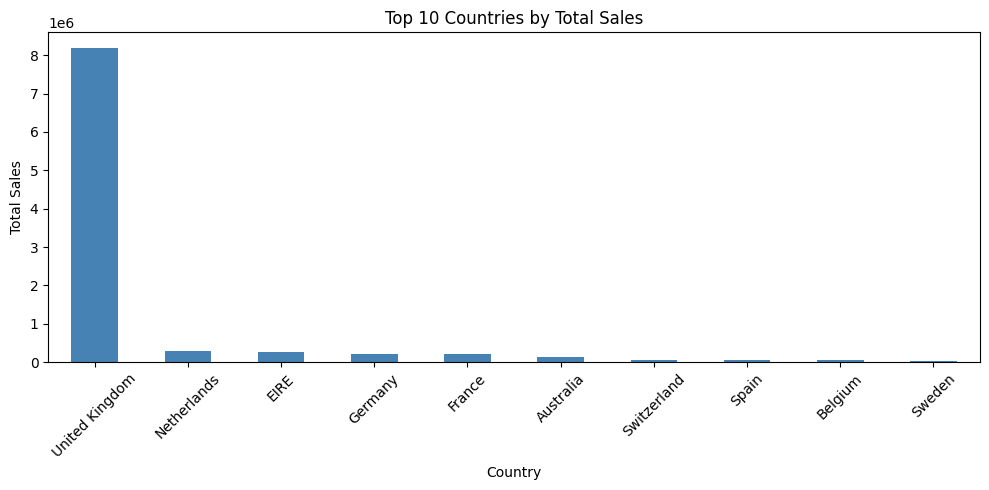

In [11]:
# Aggregate & Bar Plot (Top 10 Countries by Total Sales)
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 Countries by Total Sales:")
print(country_sales)

plt.figure(figsize=(10, 5))
country_sales.plot(kind="bar", color="steelblue")
plt.title("Top 10 Countries by Total Sales")
plt.ylabel("Total Sales")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Matrix and Heatmap

We can explore the relationships between numerical features using a correlation matrix and visualize it with a heatmap. We'll filter for valid sales (positive Quantity and UnitPrice) to avoid skew from returns.


Correlation Matrix:
            Quantity  UnitPrice  TotalSales  CustomerID
Quantity    1.000000  -0.003773    0.907338   -0.006232
UnitPrice  -0.003773   1.000000    0.137404   -0.010873
TotalSales  0.907338   0.137404    1.000000   -0.004109
CustomerID -0.006232  -0.010873   -0.004109    1.000000


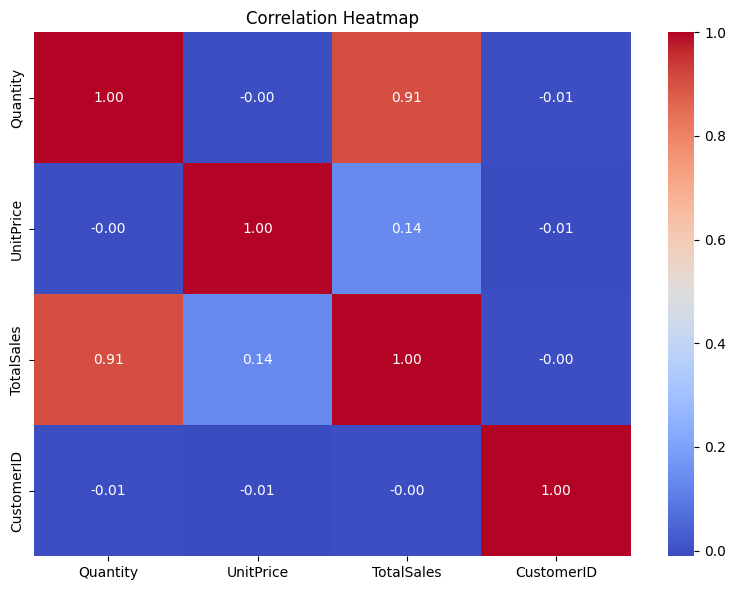

In [12]:
# Filter to positive sales records to avoid skew from returns
valid_sales = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Calculate correlation matrix
corr = valid_sales[["Quantity", "UnitPrice", "TotalSales", "CustomerID"]].corr()
print("\nCorrelation Matrix:")
print(corr)

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Scatter Plot: Quantity vs UnitPrice

Finally, let's visualize the relationship between `Quantity` and `UnitPrice` using a scatter plot, focusing on typical order sizes to prevent outliers from dominating the plot.

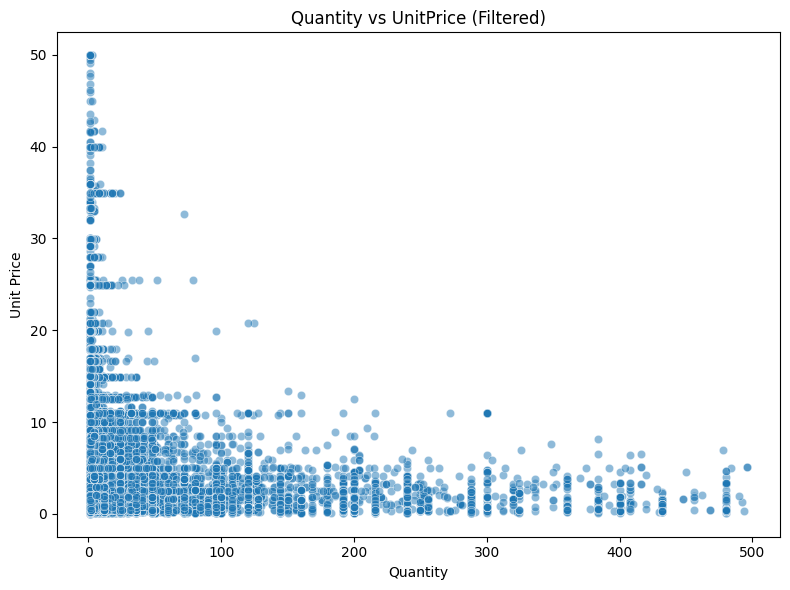

In [13]:
# Scatter Plot (Quantity vs UnitPrice for typical order sizes)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=valid_sales[(valid_sales["Quantity"] < 500) & (valid_sales["UnitPrice"] < 50)],
    x="Quantity",
    y="UnitPrice",
    alpha=0.5
)
plt.title("Quantity vs UnitPrice (Filtered)")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.tight_layout()
plt.show()